# Stellar Contamination in Transmission Spectra

When we observe a transiting exoplanet, the transmission spectrum we measure depends not only on the planet's atmosphere, but also on the stellar spectrum behind the planet. If the host star has an inhomogeneous surface --- with cool starspots and/or hot faculae --- then the spectrum of the unocculted stellar surface differs from the average stellar spectrum. This introduces a wavelength-dependent bias in the observed transit depth known as the Transit Light Source (TLS) effect ([Rackham et al. 2018](https://ui.adsabs.harvard.edu/abs/2018ApJ...853..122R)).

The contamination factor, $\epsilon(\lambda)$, acts as a multiplicative correction to the "true" atmospheric transit depth:

$$\delta_\mathrm{obs}(\lambda) = \epsilon(\lambda) \, \delta_\mathrm{atm}(\lambda)$$

where $\epsilon(\lambda) = \frac{1}{1 - \sum_i f_i \left(1 - \frac{I_i(\lambda)}{I_\mathrm{phot}(\lambda)}\right)}$, the sum runs over each heterogeneity region $i$ with covering fraction $f_i$ and specific intensity $I_i(\lambda)$, and $I_\mathrm{phot}(\lambda)$ is the photosphere intensity.

Stellar contamination is particularly important for planets orbiting M dwarfs, since these stars tend to have large spot covering fractions. An excellent case study is TRAPPIST-1, one of the most active M dwarfs known to host transiting planets. In this tutorial, we will model the impact of stellar contamination on the transmission spectrum of TRAPPIST-1 f.

This tutorial is split into two parts:

- Part 1: stellar contamination for a bare rocky planet (no atmosphere). This isolates the pure stellar contamination signal --- what you would observe even if the planet has no atmosphere at all.
- Part 2: stellar contamination for TRAPPIST-1 f with an Earth-like atmosphere, showing how stellar activity can mimic or mask atmospheric features.

Let's get started! 

### Setting Up the TRAPPIST-1 System

First, let's define the properties of TRAPPIST-1 and TRAPPIST-1 f. Since TRAPPIST-1 f is a rocky planet, we use Earth units for the planetary radius and mass.

We begin by creating a clean stellar object (no heterogeneities) to establish our baseline, and computing the flat bare rock transit depth.

In [16]:
from POSEIDON.core import create_star, create_planet, define_model, \
                        make_atmosphere, read_opacities, compute_spectrum, \
                        wl_grid_constant_R
from POSEIDON.stellar import stellar_contamination
from POSEIDON.constants import R_Sun, R_E, M_E
from POSEIDON.visuals import plot_spectra, plot_PT, plot_chem
from POSEIDON.utility import plot_collection
import numpy as np

#***** Define TRAPPIST-1 stellar properties *****#

R_s = 0.1197*R_Sun    # Stellar radius (m)
T_s = 2566.0          # Stellar effective temperature (K)
Met_s = 0.04          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 5.21        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create a clean stellar object (no heterogeneities)
star_clean = create_star(R_s, T_s, log_g_s, Met_s)

#***** Define TRAPPIST-1 f planet properties *****#

planet_name = 'TRAPPIST-1f'

R_p = 1.045*R_E      # Planetary radius (m)
M_p = 0.926*M_E      # Planetary mass (kg)
T_eq = 219.0         # Equilibrium temperature (K)

planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

#***** Set up the wavelength grid *****#

wl_min = 0.6      # Minimum wavelength (um)
wl_max = 14.0     # Maximum wavelength (um)
R = 10000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Bare rock transit depth: simply (Rp/Rs)^2 *****#

spectrum_bare_clean = (R_p / R_s)**2 * np.ones_like(wl)

print("Bare rock transit depth: {:.6f}".format(spectrum_bare_clean[0]))

Bare rock transit depth: 0.006406


### Choosing a Stellar Model Grid

To model stellar contamination, POSEIDON needs realistic stellar spectra --- not just blackbodies --- because the contamination factor $\epsilon(\lambda)$ depends on the wavelength-dependent *ratio* of the heterogeneity and photosphere specific intensities. POSEIDON supports two stellar model grids:

- `'cbk04'`: the Castelli & Kurucz (2004) atlas. These models cover a wide range of $T_\mathrm{eff}$, $\log g$, and metallicity. They are a good default choice for FGK-type stars.

- `'phoenix'`: the PHOENIX model grid (Husser et al. 2013). These models are better suited for cool stars ($T_\mathrm{eff} \lesssim 4000$ K), since they include more complete molecular line lists (e.g., TiO, VO, $\rm{H}_2 \rm{O}$) that dominate the spectra of M dwarfs.

Since TRAPPIST-1 is an ultra-cool M dwarf ($T_\mathrm{eff} \approx 2566$ K), the PHOENIX grid is the appropriate choice here. Note that using blackbodies (`'blackbody'`) is not permitted when `stellar_contam` is enabled, since blackbodies lack the molecular features that drive the wavelength-dependent contamination.

### Stellar Grid Interpolation Backend

POSEIDON can interpolate stellar model grids using two different backends, selected via the `interp_backend` argument to `create_star()`:

- `'pysynphot'` (default): installs automatically with POSEIDON, and is what we use in this tutorial.

- `'pymsg'`: uses a more accurate interpolation method and is *strongly* recommended for forward models and retrievals that include stellar contamination. However, `pymsg` requires a separate manual installation --- see the [MSG documentation](https://msg.readthedocs.io/en/stable/) for instructions.

To switch to `pymsg`, simply pass `interp_backend = 'pymsg'` when calling `create_star()`. For example:
```python
star = create_star(R_s, T_s, log_g_s, Met_s,
                   stellar_contam = 'one_spot',
                   stellar_grid = 'phoenix',
                   f_het = f_het, T_het = T_het,
                   wl = wl, interp_backend = 'pymsg')
```

<div class="alert alert-warning">

The coldest model in the `pymsg` PHOENIX grid has $T_\mathrm{eff} = 2300$ K. If your star or heterogeneity temperature falls below this limit, `pymsg` will not be able to interpolate the stellar spectrum. For the full list of available `pymsg` stellar grids and their parameter ranges, see: [http://user.astro.wisc.edu/~townsend/static.php?ref=msg-grids](http://user.astro.wisc.edu/~townsend/static.php?ref=msg-grids).

</div>

<div class="alert alert-info">

Both grids require the `PYSYN_CDBS` environment variable to point to your stellar grid data directory (see the [Installation Guide](../installation.html) for details).

</div>

## Part 1: Bare Rocky Planet with Stellar Contamination

For a bare rocky planet with no atmosphere, the transit depth is simply $(R_p / R_s)^2$ --- a flat line with no spectral features. But if the star has unocculted heterogeneities, the *observed* transit depth becomes wavelength-dependent even though the planet itself contributes no spectral features.

This is the key danger of stellar contamination: it can create the illusion of an atmosphere where none exists, or alter the inferred atmospheric properties.

We already computed the flat bare rock spectrum above. Now let's see what happens when we add a starspot to TRAPPIST-1.

### One-Spot Model: Cool Starspot on TRAPPIST-1

Now let's see what happens when TRAPPIST-1 has an unocculted cool starspot. In the `'one_spot'` model, a single heterogeneous region covers a fraction $f_\mathrm{het}$ of the visible stellar disk.

To apply stellar contamination to a forward model spectrum in POSEIDON:

1. Create a stellar object with heterogeneity properties via `create_star()`.
2. Compute $\epsilon(\lambda)$ using `stellar_contamination()` from `POSEIDON.stellar`.
3. Multiply the clean transit depth by $\epsilon(\lambda)$.

For TRAPPIST-1, photometric monitoring suggests spot covering fractions of $\sim$8--54% ([Morris et al. 2018](https://ui.adsabs.harvard.edu/abs/2018ApJ...863L..32M)). Let's adopt a moderate spot with $f_\mathrm{het} = 0.20$ and $T_\mathrm{spot} = 2266$ K (300 K cooler than the photosphere).

In [17]:
#***** One-spot model: Cool starspot *****#

f_het = 0.20             # 20% of the stellar disk is covered by the spot
T_het = T_s - 300.0      # Spot is 300 K cooler than the photosphere

# Create the star with a single heterogeneity
# We use the PHOENIX grid, which is best for cool M dwarfs
star_one_spot = create_star(R_s, T_s, log_g_s, Met_s,
                            stellar_contam = 'one_spot',
                            stellar_grid = 'phoenix',
                            f_het = f_het, T_het = T_het,
                            wl = wl)

# Compute the stellar contamination factor
epsilon_spot = stellar_contamination(star_one_spot, wl)

# Apply the contamination to the flat bare rock transit depth
spectrum_bare_spot = epsilon_spot * spectrum_bare_clean

print(f"Photosphere T_eff = {T_s:.0f} K")
print(f"Spot T_het = {T_het:.0f} K")
print(f"Spot covering fraction = {f_het:.0%}")
print(f"Mean contamination factor: {np.mean(epsilon_spot):.4f}")

Photosphere T_eff = 2566 K
Spot T_het = 2266 K
Spot covering fraction = 20%
Mean contamination factor: 1.0730


### Varying Spot Covering Fraction

Let's systematically vary the spot covering fraction to see how the contamination scales. We hold the spot temperature contrast fixed at $\Delta T = -300$ K and sweep $f_\mathrm{het}$ from 5% to 40%.

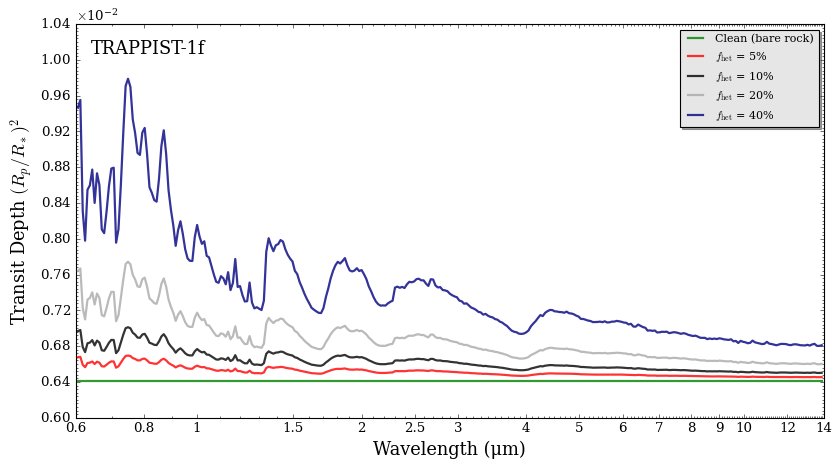

In [27]:
#***** Vary spot covering fraction *****#

f_values = [0.05, 0.10, 0.20, 0.40]
delta_T_spot = -300.0   # Spot temperature offset (K)

spectra_vary_f = plot_collection(spectrum_bare_clean, wl, collection = [])
labels_vary_f = ['Clean (bare rock)']

for f in f_values:

    # Create star with this covering fraction
    star_f = create_star(R_s, T_s, log_g_s, Met_s,
                         stellar_contam = 'one_spot',
                         stellar_grid = 'phoenix',
                         f_het = f, T_het = T_s + delta_T_spot,
                         wl = wl)

    # Compute and apply contamination
    eps = stellar_contamination(star_f, wl)
    spectrum_f = eps * spectrum_bare_clean

    spectra_vary_f = plot_collection(spectrum_f, wl, collection = spectra_vary_f)
    labels_vary_f.append(f'$f_\\mathrm{{het}}$ = {f:.0%}')

# Plot using POSEIDON's built-in plotter
fig_vary_f = plot_spectra(spectra_vary_f, planet, R_to_bin = 100,
                          plot_full_res = False,
                          spectra_labels = labels_vary_f,
                          figure_shape = 'wide')

### Varying Spot Temperature

Now let's hold the covering fraction fixed at $f_\mathrm{het} = 20\%$ and vary the temperature contrast between the spot and the photosphere. Larger temperature contrasts mean a greater difference in the spectral energy distributions of the spot and photosphere, producing stronger contamination features.

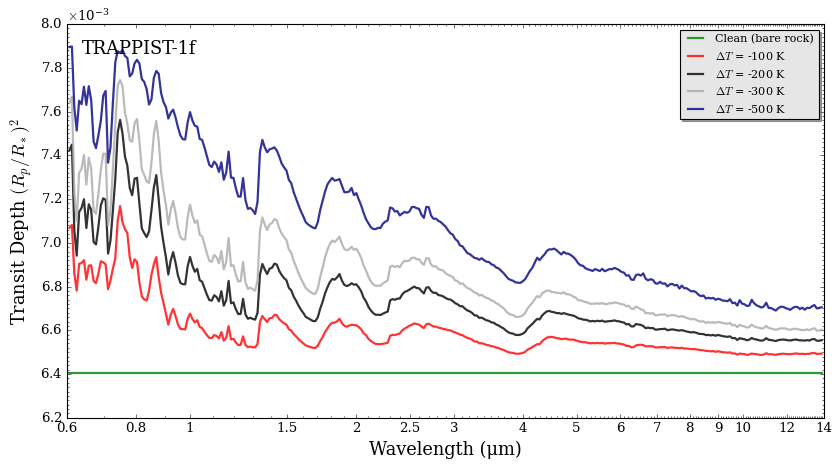

In [28]:
#***** Vary spot temperature *****#

delta_T_values = [-100, -200, -300, -500]
f_het_fixed = 0.20

spectra_vary_T = plot_collection(spectrum_bare_clean, wl, collection = [])
labels_vary_T = ['Clean (bare rock)']

for dT in delta_T_values:

    star_dT = create_star(R_s, T_s, log_g_s, Met_s,
                          stellar_contam = 'one_spot',
                          stellar_grid = 'phoenix',
                          f_het = f_het_fixed, T_het = T_s + dT,
                          wl = wl)

    eps_dT = stellar_contamination(star_dT, wl)
    spectrum_dT = eps_dT * spectrum_bare_clean

    spectra_vary_T = plot_collection(spectrum_dT, wl, collection = spectra_vary_T)
    labels_vary_T.append(f'$\\Delta T$ = {dT:+d} K')

fig_vary_T = plot_spectra(spectra_vary_T, planet, R_to_bin = 100,
                          plot_full_res = False,
                          spectra_labels = labels_vary_T,
                          figure_shape = 'wide')

### One-Spot Model: Hot Faculae

Faculae are regions on the stellar surface that are *hotter* than the surrounding photosphere --- the opposite of starspots. On M dwarfs, faculae are associated with magnetically active regions and can cover a significant fraction of the stellar disk.

We can model faculae using the same `'one_spot'` framework by setting $T_\mathrm{het} > T_\mathrm{eff}$. While spots inflate the observed transit depth (since the unocculted photosphere appears brighter relative to the spotted regions), faculae *decrease* the apparent transit depth.

Let's explore faculae contamination by varying the covering fraction and temperature, just as we did for spots.

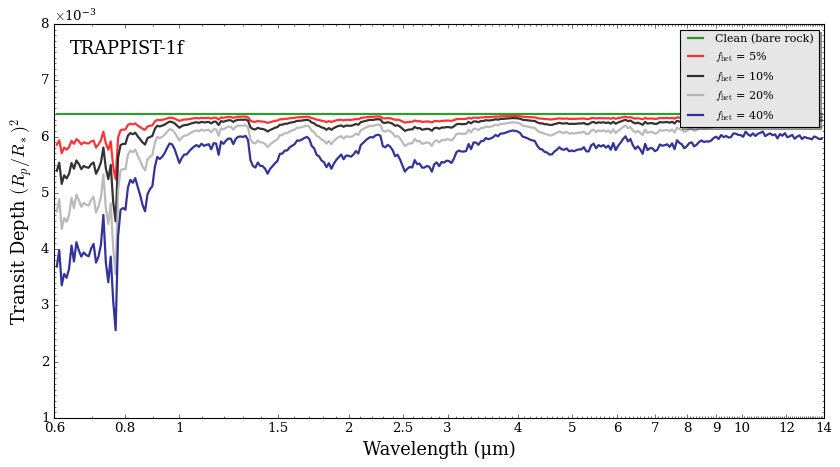

In [29]:
#***** Vary faculae covering fraction *****#

f_fac_values = [0.05, 0.10, 0.20, 0.40]
delta_T_fac = 200.0   # Faculae are 200 K hotter than the photosphere

spectra_vary_f_fac = plot_collection(spectrum_bare_clean, wl, collection = [])
labels_vary_f_fac = ['Clean (bare rock)']

for f in f_fac_values:

    star_fac = create_star(R_s, T_s, log_g_s, Met_s,
                           stellar_contam = 'one_spot',
                           stellar_grid = 'phoenix',
                           f_het = f, T_het = T_s + delta_T_fac,
                           wl = wl)

    eps_fac = stellar_contamination(star_fac, wl)
    spectrum_fac = eps_fac * spectrum_bare_clean

    spectra_vary_f_fac = plot_collection(spectrum_fac, wl, collection = spectra_vary_f_fac)
    labels_vary_f_fac.append(f'$f_\\mathrm{{het}}$ = {f:.0%}')

fig_vary_f_fac = plot_spectra(spectra_vary_f_fac, planet, R_to_bin = 100,
                              plot_full_res = False,
                              spectra_labels = labels_vary_f_fac,
                              figure_shape = 'wide')

### Varying Faculae Temperature

Let's hold the faculae covering fraction fixed at $f_\mathrm{het} = 10\%$ and vary the temperature contrast.

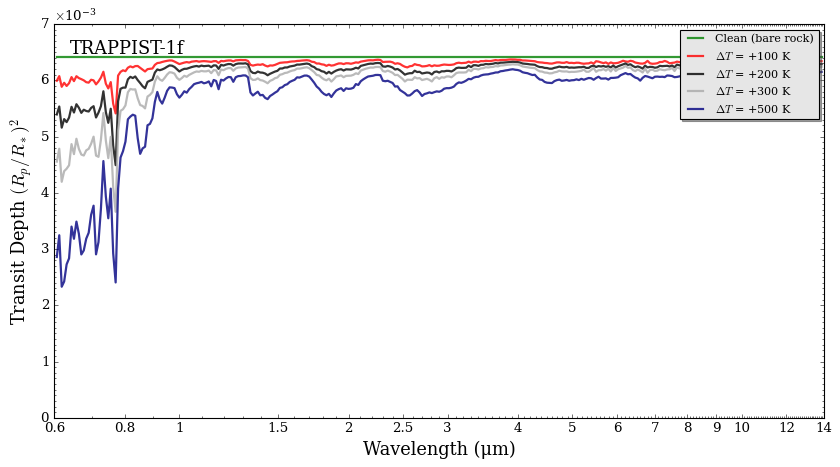

In [30]:
#***** Vary faculae temperature *****#

delta_T_fac_values = [100, 200, 300, 500]
f_fac_fixed = 0.10

spectra_vary_T_fac = plot_collection(spectrum_bare_clean, wl, collection = [])
labels_vary_T_fac = ['Clean (bare rock)']

for dT in delta_T_fac_values:

    star_fac_dT = create_star(R_s, T_s, log_g_s, Met_s,
                              stellar_contam = 'one_spot',
                              stellar_grid = 'phoenix',
                              f_het = f_fac_fixed, T_het = T_s + dT,
                              wl = wl)

    eps_fac_dT = stellar_contamination(star_fac_dT, wl)
    spectrum_fac_dT = eps_fac_dT * spectrum_bare_clean

    spectra_vary_T_fac = plot_collection(spectrum_fac_dT, wl, collection = spectra_vary_T_fac)
    labels_vary_T_fac.append(f'$\\Delta T$ = +{dT} K')

fig_vary_T_fac = plot_spectra(spectra_vary_T_fac, planet, R_to_bin = 100,
                              plot_full_res = False,
                              spectra_labels = labels_vary_T_fac,
                              figure_shape = 'wide')

Notice how faculae produce the opposite effect compared to starspots: the observed transit depth *decreases* because the unocculted faculae make the stellar disk brighter than a uniform photosphere would be. The spectral shape of the contamination is also different, since the hotter faculae have a bluer spectral energy distribution.

### Two-Spots Model: Spots + Faculae

Real stellar surfaces typically have both cool spots and hot faculae simultaneously. POSEIDON supports this with the `'two_spots'` contamination model. In this model:

- A fraction $f_\mathrm{spot}$ of the disk has spots at temperature $T_\mathrm{spot}$.
- A fraction $f_\mathrm{fac}$ of the disk has faculae at temperature $T_\mathrm{fac}$.
- The remaining fraction $(1 - f_\mathrm{spot} - f_\mathrm{fac})$ is the photosphere.

Note the constraints: $T_\mathrm{spot} < T_\mathrm{eff} < T_\mathrm{fac}$ and $f_\mathrm{spot} + f_\mathrm{fac} < 1$.

Let's set up a two-spots model and compare all three contamination scenarios side by side.

Spot: f = 20%, T = 2266 K
Faculae: f = 10%, T = 2766 K
Mean contamination factor (two-spots): 1.0263


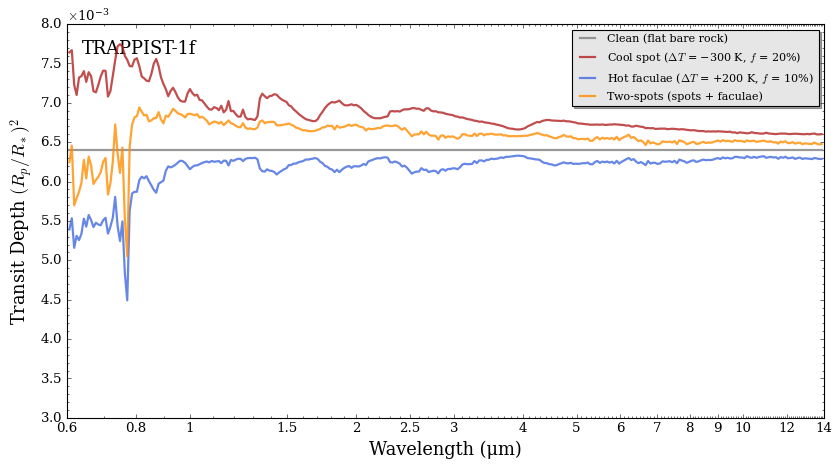

In [31]:
#***** Two-spots model: Spots + Faculae *****#

f_spot = 0.20          # 20% spot coverage
T_spot = T_s - 300.0   # Spot is 300 K cooler (2266 K)

f_fac = 0.10           # 10% faculae coverage
T_fac = T_s + 200.0    # Facula is 200 K hotter (2766 K)

# Create the star with both spots and faculae
star_two_spots = create_star(R_s, T_s, log_g_s, Met_s,
                             stellar_contam = 'two_spots',
                             stellar_grid = 'phoenix',
                             f_spot = f_spot, f_fac = f_fac,
                             T_spot = T_spot, T_fac = T_fac,
                             wl = wl)

# Compute the contamination factor
epsilon_two = stellar_contamination(star_two_spots, wl)

# Apply the contamination
spectrum_bare_two = epsilon_two * spectrum_bare_clean

print(f"Spot: f = {f_spot:.0%}, T = {T_spot:.0f} K")
print(f"Faculae: f = {f_fac:.0%}, T = {T_fac:.0f} K")
print(f"Mean contamination factor (two-spots): {np.mean(epsilon_two):.4f}")

#***** Also create faculae-only for the comparison plot *****#

star_faculae = create_star(R_s, T_s, log_g_s, Met_s,
                           stellar_contam = 'one_spot',
                           stellar_grid = 'phoenix',
                           f_het = f_fac, T_het = T_fac,
                           wl = wl)

epsilon_fac = stellar_contamination(star_faculae, wl)
spectrum_bare_fac = epsilon_fac * spectrum_bare_clean

#***** Compare all contamination models *****#

spectra_bare = plot_collection(spectrum_bare_clean, wl, collection = [])
spectra_bare = plot_collection(spectrum_bare_spot, wl, collection = spectra_bare)
spectra_bare = plot_collection(spectrum_bare_fac, wl, collection = spectra_bare)
spectra_bare = plot_collection(spectrum_bare_two, wl, collection = spectra_bare)

fig_bare = plot_spectra(spectra_bare, planet, R_to_bin = 100,
                        plot_full_res = False,
                        spectra_labels = ['Clean (flat bare rock)',
                                          'Cool spot ($\\Delta T$ = −300 K, $f$ = 20%)',
                                          'Hot faculae ($\\Delta T$ = +200 K, $f$ = 10%)',
                                          'Two-spots (spots + faculae)'],
                        figure_shape = 'wide',
                        colour_list = ['grey', 'firebrick', 'royalblue', 'darkorange'])

With both spots and faculae present, the contamination partially cancels out: cool spots push the transit depth up while hot faculae push it down. But the cancellation is not perfect --- it is wavelength-dependent, so the net contamination still distorts the spectral shape. Whether the overall transit depth is inflated or deflated depends on the relative covering fractions and temperature contrasts of spots and faculae.

For TRAPPIST-1, photometric monitoring suggests large spot covering fractions ($\sim$8--54%, [Morris et al. 2018](https://ui.adsabs.harvard.edu/abs/2018ApJ...863L..32M)), making stellar contamination a critical systematic to account for when interpreting JWST transmission spectra.

## Part 2: Earth-like Atmosphere with Stellar Contamination

Now let's add an atmosphere to TRAPPIST-1 f and see how stellar contamination interacts with real atmospheric features. We'll use a simple Earth-like model with $\rm{N}_2$ as the bulk gas and $\rm{CO}_2$ and $\rm{H}_2 \rm{O}$ as trace species, with isothermal temperature and isochemical abundance profiles for simplicity.

This lets us directly compare the atmospheric signal to the stellar contamination signal.

In [21]:
#***** Define the Earth-like atmosphere model *****#

model_name_atm = 'Earth-like'

bulk_species_atm = ['N2']
param_species_atm = ['CO2', 'H2O']

model_atm = define_model(model_name_atm, bulk_species_atm, param_species_atm,
                         PT_profile = 'isotherm', X_profile = 'isochem',
                         cloud_model = 'cloud-free', radius_unit = 'R_E',
                         surface = True)

#***** Set up the pressure grid *****#

P_min = 1.0e-7    # 0.1 ubar
P_max = 10.0      # 10 bar
N_layers = 100    # 100 layers

P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

#***** Create the atmosphere *****#

P_surf = 1.0       # Surface pressure (bar)
P_ref = P_surf     # Reference pressure at the surface
R_p_ref = R_p      # Radius at reference pressure

PT_params_atm = np.array([250])                  # Isothermal at 250 K
log_X_params_atm = np.array([-3.4, -3.0])        # log10(CO2) ~ 400 ppm, log10(H2O) ~ 1000 ppm

atmosphere_atm = make_atmosphere(planet, model_atm, P, P_ref, R_p_ref,
                                  PT_params_atm, log_X_params_atm,
                                  P_surf = P_surf)

#***** Read opacities for the atmospheric species *****#

opacity_treatment = 'opacity_sampling'

T_fine = np.arange(100, 310, 10)
log_P_fine = np.arange(-6.0, 2.2, 0.2)

opac_atm = read_opacities(model_atm, wl, opacity_treatment, T_fine, log_P_fine,
                          opacity_database = 'Temperate')

print("Model free parameters: " + str(model_atm['param_names']))

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
N2-N2 done
N2-H2O done
CO2 done
H2O done
Opacity pre-interpolation complete.
Model free parameters: ['R_p_ref' 'log_P_surf' 'T' 'log_CO2' 'log_H2O']


Let's visualise the atmospheric structure before computing the spectrum.

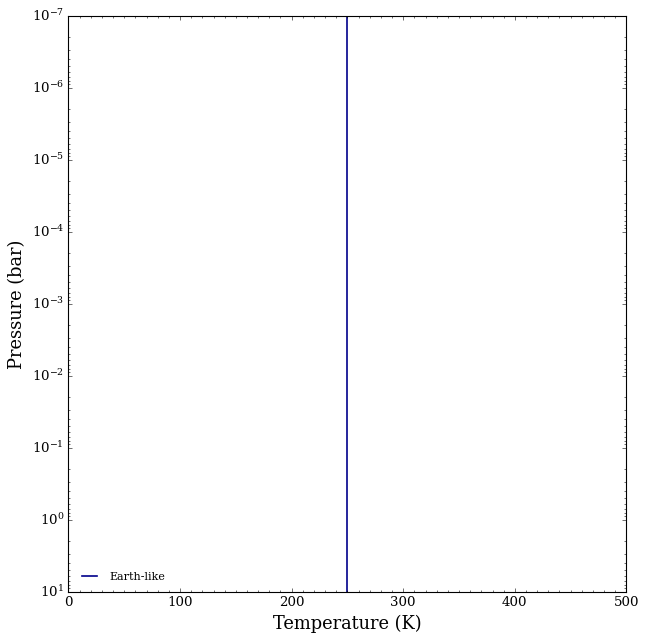

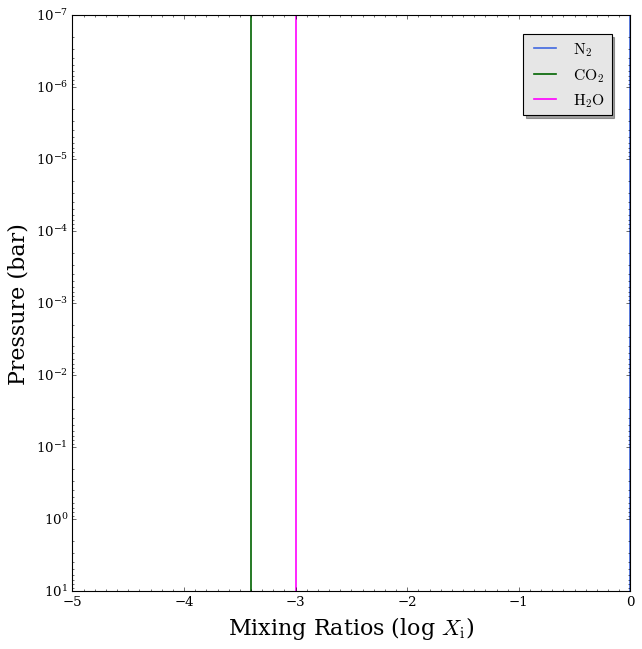

In [22]:
#***** Plot the P-T profile *****#

fig_PT = plot_PT(planet, model_atm, atmosphere_atm)

#***** Plot the mixing ratio profiles *****#

fig_chem = plot_chem(planet, model_atm, atmosphere_atm)

### Clean Atmospheric Spectrum

First, let's compute the transmission spectrum of TRAPPIST-1 f's Earth-like atmosphere without any stellar contamination.

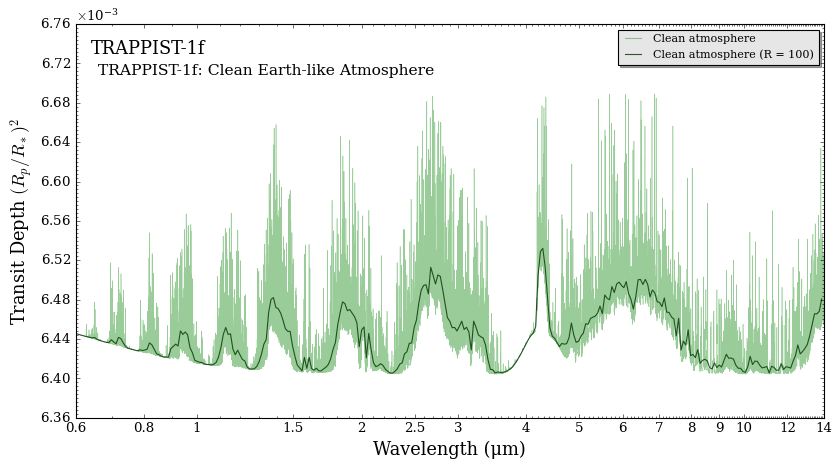

In [23]:
#***** Compute the clean atmospheric spectrum *****#

spectrum_atm_clean = compute_spectrum(planet, star_clean, model_atm, atmosphere_atm,
                                     opac_atm, wl,
                                     spectrum_type = 'transmission')

#***** Plot the clean atmospheric spectrum *****#

spectra_atm_clean_coll = plot_collection(spectrum_atm_clean, wl, collection = [])

fig_clean_atm = plot_spectra(spectra_atm_clean_coll, planet,
                             spectra_labels = ['Clean atmosphere'],
                             figure_shape = 'wide',
                             R_to_bin = 100,
                             plt_label = 'TRAPPIST-1f: Clean Earth-like Atmosphere')

### Contaminated Atmospheric Spectra

Now let's apply our stellar contamination models to the atmospheric spectrum. We reuse the same $\epsilon(\lambda)$ arrays from Part 1.

The contamination factor $\varepsilon(\lambda)$ acts as a multiplicative scaling on the transit depth:

$$\left(\frac{R_p}{R_\star}\right)^2_{\rm obs} = \varepsilon(\lambda) \times \left(\frac{R_p}{R_\star}\right)^2_{\rm true}$$

When applied to an atmosphere with spectral features, the contamination both shifts the baseline transit depth and distorts the relative strength of molecular absorption bands.

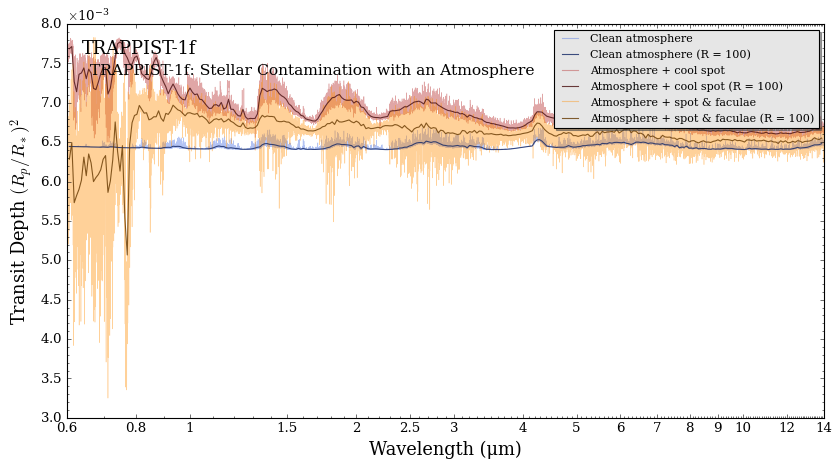

In [24]:
#***** Apply stellar contamination to the atmospheric spectrum *****#

# One-spot model (cool spot only)
spectrum_atm_spot = spectrum_atm_clean * epsilon_spot

# Two-spots model (spot + faculae)
spectrum_atm_two = spectrum_atm_clean * epsilon_two

#***** Compare clean vs. contaminated atmospheric spectra *****#

spectra_atm_comp = plot_collection(spectrum_atm_clean, wl, collection = [])
spectra_atm_comp = plot_collection(spectrum_atm_spot, wl, collection = spectra_atm_comp)
spectra_atm_comp = plot_collection(spectrum_atm_two, wl, collection = spectra_atm_comp)

fig_contam_atm = plot_spectra(spectra_atm_comp, planet,
                              spectra_labels = ['Clean atmosphere',
                                                'Atmosphere + cool spot',
                                                'Atmosphere + spot & faculae'],
                              figure_shape = 'wide',
                              R_to_bin = 100,
                              colour_list = ['royalblue', 'firebrick', 'darkorange'],
                              plt_label = 'TRAPPIST-1f: Stellar Contamination with an Atmosphere')

Notice how stellar contamination not only shifts the overall transit depth but also introduces wavelength-dependent distortions that can mimic or mask real atmospheric absorption features. This is the central challenge for characterising terrestrial exoplanet atmospheres around M dwarfs.

### Bare Rock vs. Atmosphere: A Combined View

Finally, let's compare all our spectra side-by-side to see how the interplay of a planetary atmosphere and stellar surface heterogeneity shapes the observed transit spectrum.

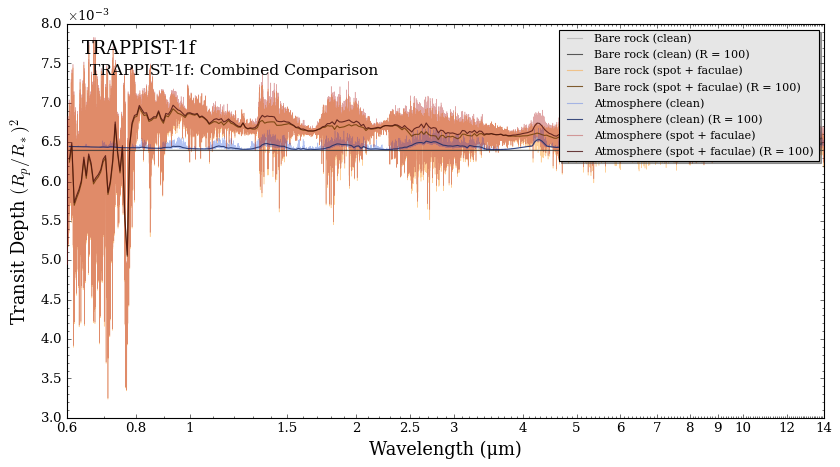

In [25]:
#***** Combined comparison: bare rock vs. atmosphere, clean vs. contaminated *****#

spectra_combined = plot_collection(spectrum_bare_clean, wl, collection = [])
spectra_combined = plot_collection(spectrum_bare_two, wl, collection = spectra_combined)
spectra_combined = plot_collection(spectrum_atm_clean, wl, collection = spectra_combined)
spectra_combined = plot_collection(spectrum_atm_two, wl, collection = spectra_combined)

fig_combined = plot_spectra(spectra_combined, planet,
                            spectra_labels = ['Bare rock (clean)',
                                              'Bare rock (spot + faculae)',
                                              'Atmosphere (clean)',
                                              'Atmosphere (spot + faculae)'],
                            figure_shape = 'wide',
                            R_to_bin = 100,
                            colour_list = ['grey', 'darkorange',
                                           'royalblue', 'firebrick'],
                            plt_label = 'TRAPPIST-1f: Combined Comparison')